<a href="https://colab.research.google.com/github/nurqalbuam-design/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_Responsi_Minggu_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [63]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1021)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 10.5
beta0 = 31
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


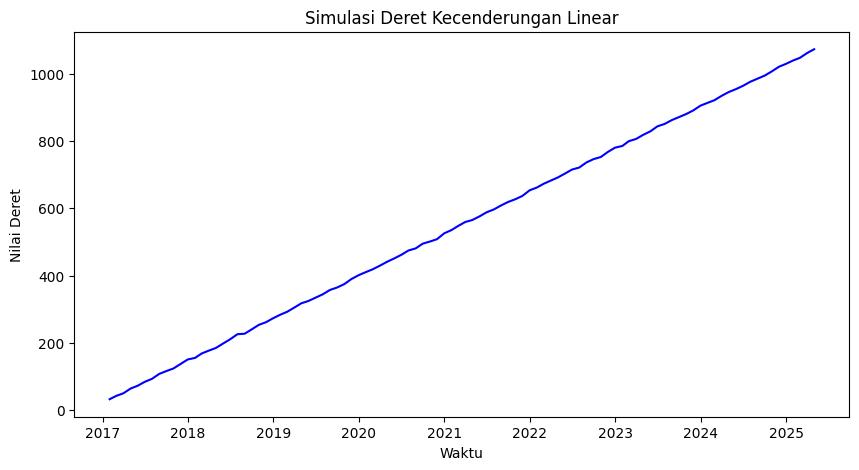

In [64]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Berdasarkan grafik simulasi deret waktu, terlihat bahwa nilai deret mengalami peningkatan secara konsisten dari awal hingga akhir periode. Pola yang terbentuk cenderung berupa garis lurus dengan arah positif, sehingga menunjukkan adanya kecenderungan linear positif yang kuat. Hal ini berarti bahwa semakin bertambah waktu, nilai deret juga semakin meningkat. Fluktuasi kecil di sekitar garis kecenderungan disebabkan oleh komponen noise yang ditambahkan pada proses simulasi.

In [65]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


Nilai korelasi antara waktu dan nilai deret sebesar 1,0000 menunjukkan adanya hubungan linear positif yang sangat kuat antara waktu dan nilai deret. Artinya, peningkatan waktu diikuti oleh peningkatan nilai deret secara hampir sempurna. Besarnya korelasi tersebut terjadi karena komponen kecenderungan linear pada data jauh lebih dominan dibandingkan noise.

In [66]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.375e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.17e-216
Time:                        13:18:33   Log-Likelihood:                -208.51
No. Observations:                 100   AIC:                             421.0
Df Residuals:                      98   BIC:                             426.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           31.1312      0.390     79.747   

### Interpretasi Hasil Regresi Linear

Berdasarkan hasil regresi, diperoleh model:

$$
\hat{Y}_t = 31.1312 + 10.4982t
$$

Nilai konstanta sebesar 31.1312 merupakan nilai dugaan $Y$ ketika $t=0$. Sementara itu, koefisien waktu sebesar 10.4982 menunjukkan bahwa setiap penambahan satu periode waktu akan meningkatkan nilai deret sekitar 10.4982 satuan.

Nilai $R^2$ sebesar 1.000 menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh waktu. Selain itu, nilai Prob(F-statistic) < 0.05, sehingga model regresi secara keseluruhan signifikan.

Koefisien waktu juga memiliki p-value = 0.000 < 0.05, sehingga waktu berpengaruh signifikan terhadap nilai deret. Dengan demikian, terdapat kecenderungan linear positif yang signifikan pada data.

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Parameter asli yang digunakan pada simulasi adalah beta_0=31 dan beta_1=10.5, sedangkan hasil estimasi regresi menghasilkan konstanta sebesar 31.1312 dan koefisien waktu sebesar 10.4982. Nilai hasil estimasi sangat dekat dengan parameter asli. Perbedaan yang kecil terjadi karena data simulasi mengandung noise acak. Oleh karena itu, dapat disimpulkan bahwa model regresi mampu mengestimasi parameter kecenderungan linear dengan sangat baik.


Apakah model regresi yang dipaskan sudah bagus?

Model regresi yang diperoleh sudah dapat dikatakan sangat baik. Hal ini terlihat dari nilai R^2 sebesar 1.000 yang menunjukkan bahwa hampir seluruh variasi data dapat dijelaskan oleh model. Nilai Prob(F-statistic) juga lebih kecil dari 0.05, sehingga model secara keseluruhan signifikan. Selain itu, koefisien waktu juga signifikan dan nilainya sangat dekat dengan parameter asli yang digunakan pada simulasi. Jadi, model regresi sudah mampu menggambarkan pola kecenderungan linear pada data dengan baik. Namun, untuk memastikan model benar-benar sesuai, tetap perlu dilakukan pengecekan terhadap residualnya.

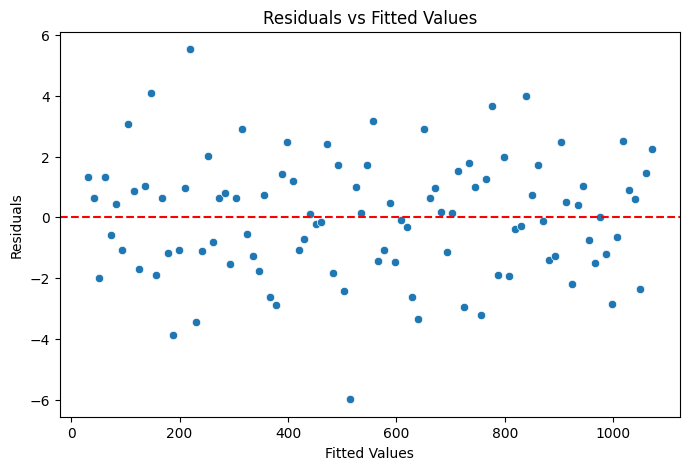

In [67]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?


Pada plot **Residuals vs Fitted Values**, residual terlihat menyebar di sekitar garis nol tanpa membentuk pola tertentu. Tidak terlihat pola melengkung maupun pola yang semakin melebar atau menyempit. Secara visual, hal ini menunjukkan bahwa bentuk model linear sudah cukup sesuai dan varians residual relatif konstan.

In [68]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.4977


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?


Dari uji Breusch-Pagan diperoleh:

$$
p\text{-value} = 0.4977
$$

Karena $p\text{-value} > 0.05$, maka tidak terdapat cukup bukti untuk menyatakan adanya heteroskedastisitas. Dengan demikian, residual dapat dianggap memiliki varians yang relatif konstan atau memenuhi asumsi homoskedastisitas.

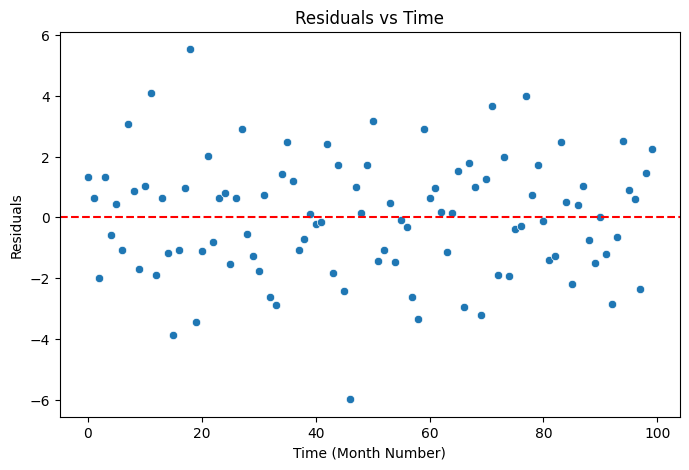

In [69]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

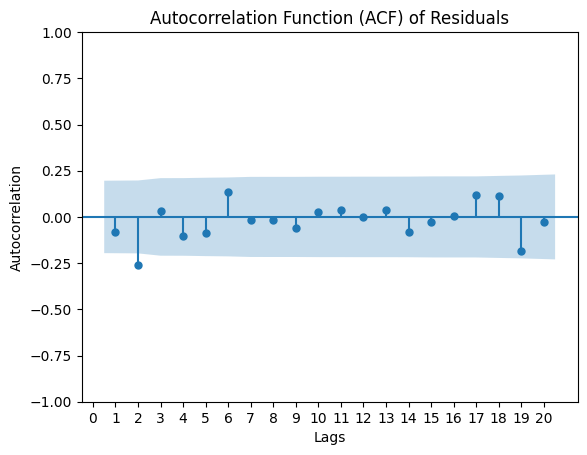

In [70]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

### Interpretasi Residuals vs Time

Plot residual terhadap waktu menunjukkan bahwa residual bergerak secara acak di sekitar nol. Tidak terlihat adanya pola naik, turun, maupun pola tertentu yang konsisten sepanjang waktu. Hal ini menunjukkan bahwa pola kecenderungan utama pada data sudah cukup baik ditangkap oleh model.

### Interpretasi ACF Residual

Pada plot ACF, sebagian besar nilai autokorelasi berada di sekitar nol dan masih berada dalam batas kepercayaan. Hal ini menunjukkan bahwa secara umum residual tidak memiliki pola autokorelasi yang kuat. Walaupun terdapat beberapa lag yang terlihat lebih besar dibandingkan lag lainnya, pola tersebut tidak muncul secara konsisten.

In [71]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.665135   0.414753
2    7.619573   0.022153
3    7.738076   0.051747
4    8.924486   0.063015
5    9.769833   0.082026
6   11.758260   0.067584
7   11.787270   0.107775
8   11.816075   0.159601
9   12.209714   0.201743
10  12.293533   0.265892
11  12.447831   0.330939
12  12.448185   0.410389
13  12.626937   0.477023
14  13.384348   0.496508
15  13.487664   0.564686
16  13.491258   0.636556
17  15.283039   0.575103
18  16.953833   0.526281
19  21.153934   0.328358


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

### Interpretasi Uji Ljung-Box

Hasil uji Ljung-Box menunjukkan bahwa pada sebagian besar lag, $p\text{-value} > 0.05$, sehingga tidak terdapat bukti autokorelasi yang signifikan pada lag-lag tersebut.

Namun, pada beberapa lag awal terdapat $p\text{-value} < 0.05$, misalnya pada lag 2 dengan $p\text{-value}$ sekitar 0.022. Hal ini menunjukkan bahwa masih terdapat indikasi autokorelasi pada lag tertentu.

Meskipun demikian, pola tersebut tidak muncul secara konsisten pada seluruh lag, sehingga secara umum autokorelasi residual tidak terlalu kuat.

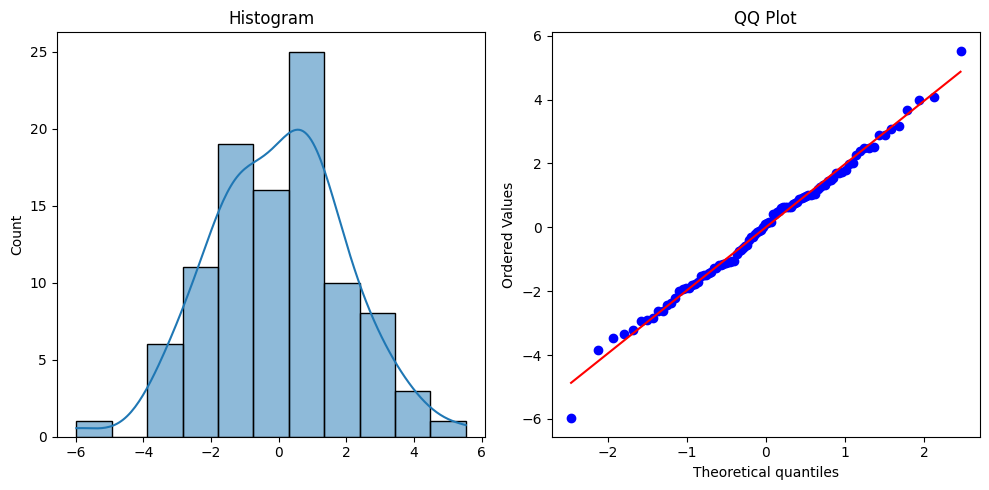

In [72]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

### Interpretasi Histogram dan QQ Plot

Histogram residual terlihat cukup simetris dan secara umum mendekati bentuk distribusi normal. Pada QQ Plot, sebagian besar titik juga berada cukup dekat dengan garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor.

Secara visual, residual dapat dikatakan cukup mendekati distribusi normal.

In [73]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9948946764274973, p-value = 0.9723457895921532


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

### Interpretasi Uji Shapiro-Wilk

Berdasarkan uji Shapiro-Wilk diperoleh:

$$
p\text{-value} = 0.9723
$$

Karena $p\text{-value} > 0.05$, maka tidak terdapat cukup bukti untuk menolak asumsi normalitas. Dengan demikian, residual dapat dianggap berdistribusi normal.

Hasil ini juga sejalan dengan histogram dan QQ Plot sebelumnya yang menunjukkan bahwa residual secara visual cukup mendekati distribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [74]:
# Menentukan parameter simulasi
np.random.seed(1021)
n_periods = 120
beta_0, beta_1, beta_2 = 71, 10.5, 0.42
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

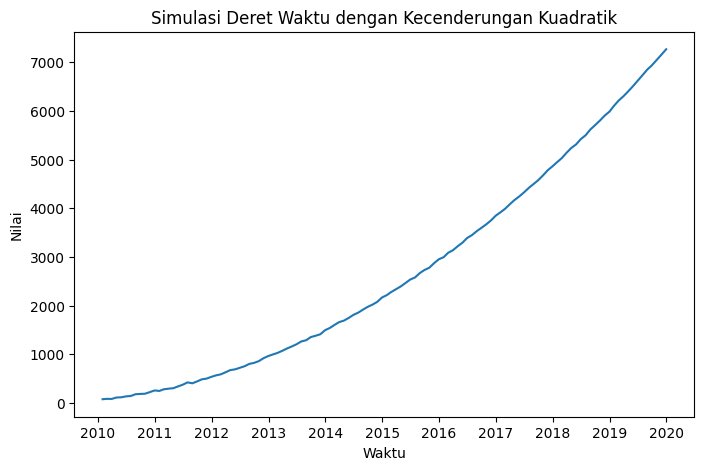

In [75]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

### Interpretasi

Berdasarkan grafik, nilai deret meningkat dari waktu ke waktu dan kenaikannya terlihat semakin cepat. Polanya tidak lagi membentuk garis lurus, tetapi melengkung ke atas. Hal ini menunjukkan adanya kecenderungan kuadratik positif. Berbeda dengan kecenderungan linear yang memiliki pertambahan relatif tetap, pada kecenderungan kuadratik besarnya kenaikan berubah seiring bertambahnya waktu. Semakin besar nilai waktu, semakin cepat pula peningkatan nilai deret.

In [76]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.974e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.87e-276
Time:                        13:18:34   Log-Likelihood:                -440.44
No. Observations:                 120   AIC:                             886.9
Df Residuals:                     117   BIC:                             895.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         72.2732      2.592     27.886      0.0

### Interpretasi Hasil Regresi Kuadratik

Berdasarkan hasil regresi, diperoleh model:

$$
\hat{Y}_t = 72.2732 + 10.4709t + 0.4200t^2
$$

Nilai konstanta sebesar 72.2732 merupakan nilai dugaan $Y$ ketika $t=0$. Koefisien $t$ sebesar 10.4709 menunjukkan adanya komponen kecenderungan linear positif. Sementara itu, koefisien $t^2$ sebesar 0.4200 menunjukkan adanya kecenderungan kuadratik positif yang menyebabkan kenaikan nilai deret menjadi semakin cepat seiring bertambahnya waktu.

Parameter asli yang digunakan pada simulasi adalah:

$$
\beta_0 = 71,\qquad
\beta_1 = 10.5,\qquad
\beta_2 = 0.42
$$

Nilai hasil estimasi cukup dekat dengan parameter asli. Perbedaan kecil yang muncul disebabkan oleh adanya noise pada data simulasi.

Nilai $R^2$ sebesar 1.000 menunjukkan bahwa hampir seluruh variasi data dapat dijelaskan oleh model kuadratik. Selain itu, seluruh koefisien memiliki $p\text{-value} < 0.05$, sehingga komponen linear maupun kuadratik berpengaruh signifikan terhadap nilai deret.

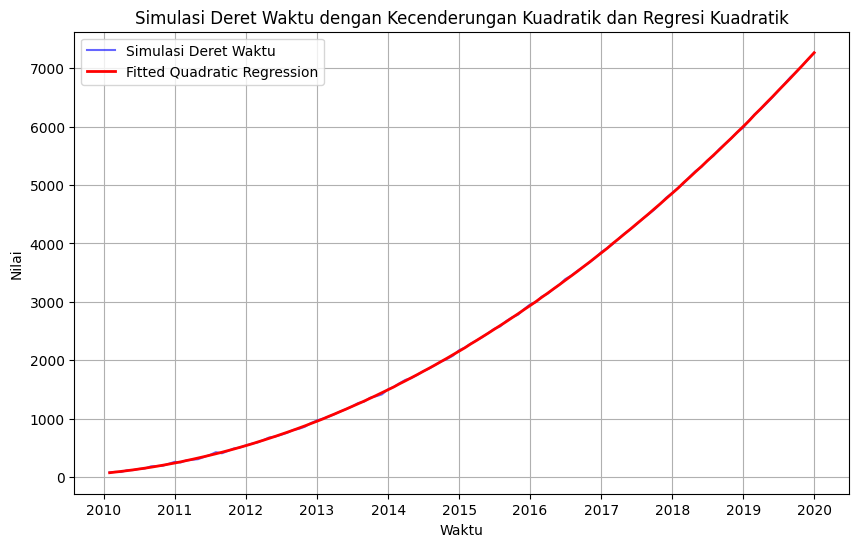

In [77]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

### Interpretasi Grafik

Pada grafik terlihat bahwa garis hasil **Fitted Quadratic Regression** hampir berimpit dengan garis data simulasi deret waktu. Hal ini menunjukkan bahwa model regresi kuadratik mampu mengikuti pola kelengkungan data dengan sangat baik.

Bentuk kurva yang semakin meningkat menunjukkan adanya kecenderungan kuadratik positif. Kedekatan antara nilai fitted dan data simulasi juga sesuai dengan hasil regresi yang memiliki nilai $R^2$ sangat tinggi, sehingga model dapat dikatakan mampu menjelaskan pola deret dengan baik.


**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

Berdasarkan output regresi, nilai **Durbin-Watson** sekitar 2.168, yaitu cukup dekat dengan 2. Hal ini menunjukkan bahwa tidak terdapat indikasi autokorelasi residual yang kuat.

Selain itu, nilai **Prob(Jarque-Bera)** sekitar 0.910 dan lebih besar dari 0.05, sehingga tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi. Dari hasil tersebut, secara umum tidak terlihat adanya pelanggaran asumsi model yang serius.


**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

Model regresi kuadratik dapat dikatakan sudah tepat untuk menggambarkan deret tersebut. Hal ini terlihat dari garis fitted yang hampir berimpit dengan data simulasi, nilai $R^2$ yang sangat tinggi, serta koefisien regresi yang signifikan.

Selain itu, hasil pemeriksaan asumsi juga menunjukkan bahwa residual tidak mengalami masalah autokorelasi yang kuat dan masih memenuhi asumsi normalitas. Oleh karena itu, model regresi kuadratik sudah mampu menggambarkan pola kecenderungan pada deret dengan baik.

In [78]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [79]:
# Menentukan parameter simulasi
np.random.seed(1021)
n_periods = 120
beta0, beta1, beta2 = 71, -525, -42
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


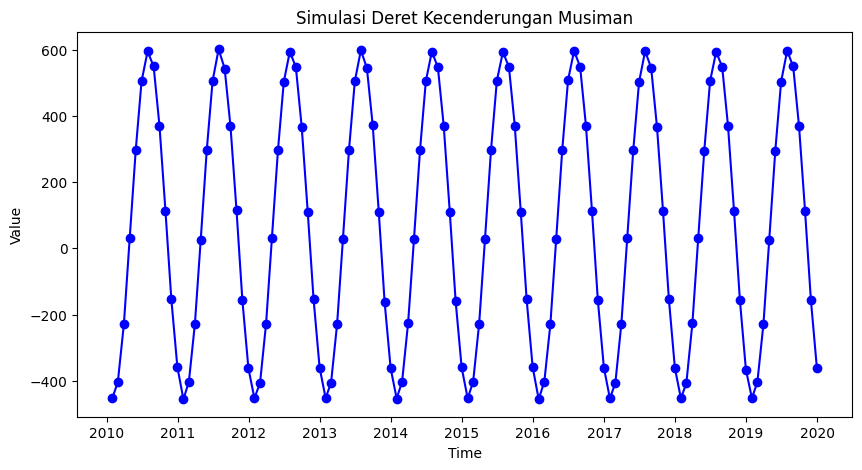

In [80]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Grafik menunjukkan pola naik dan turun yang berulang secara teratur. Karena data menggunakan periode bulanan dan pola berulang setiap 12 periode, maka deret memiliki pola musiman tahunan. Nilai maksimum dan minimum muncul pada posisi yang relatif sama pada setiap siklus. Selain itu, tidak terlihat adanya kecenderungan naik atau turun jangka panjang yang kuat. Jadi, pola utama pada deret ini adalah pola musiman.

In [81]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [82]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [83]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [84]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.307e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.15e-245
Time:                        13:18:34   Log-Likelihood:                -239.31
No. Observations:                 120   AIC:                             502.6
Df Residuals:                     108   BIC:                             536.1
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -453.7086      0.593   -765.672      0.0

Bagaimana interpretasi dari hasil tersebut?

Pada model ini digunakan 12 variabel dummy bulan tanpa intercept. Karena model tidak menggunakan intercept, setiap koefisien dapat langsung diinterpretasikan sebagai perkiraan rata-rata nilai deret pada bulan tersebut.

Hasil estimasi yang diperoleh antara lain:

- Januari = **-453.7086**
- Februari = **-404.6560**
- Maret = **-227.9945**
- April = **28.8523**
- Mei = **296.3356**
- Juni = **505.1380**
- Juli = **596.0042**
- Agustus = **547.2612**
- September = **369.5033**
- Oktober = **111.6233**
- November = **-155.7531**
- Desember = **-361.2414**

Sebagai contoh, koefisien Januari sebesar **-453.7086** menunjukkan bahwa rata-rata nilai deret pada Januari diperkirakan sebesar -453.7086. Sementara itu, koefisien Juli sebesar **596.0042** menunjukkan bahwa rata-rata nilai deret pada Juli diperkirakan sebesar 596.0042.

Nilai $R^2$ sebesar **1.000** menunjukkan bahwa pola bulanan hampir sepenuhnya mampu menjelaskan variasi data. Selain itu, koefisien bulan memiliki $p\text{-value} < 0.05$, sehingga pola musiman yang terbentuk signifikan.

In [85]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

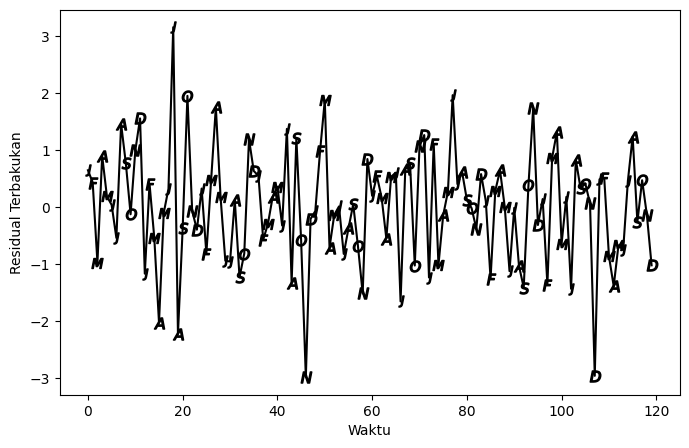

In [86]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


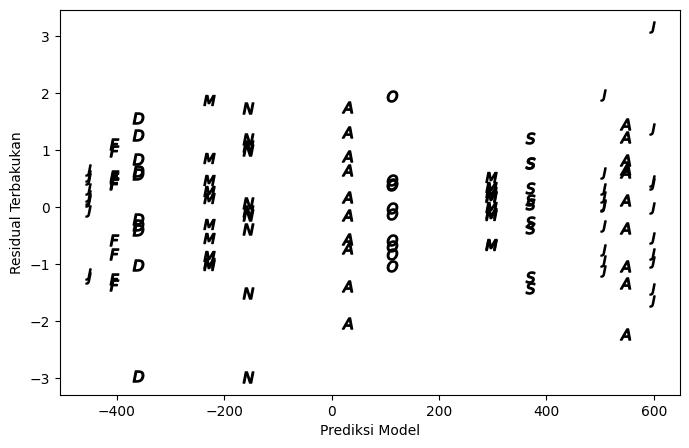

In [87]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

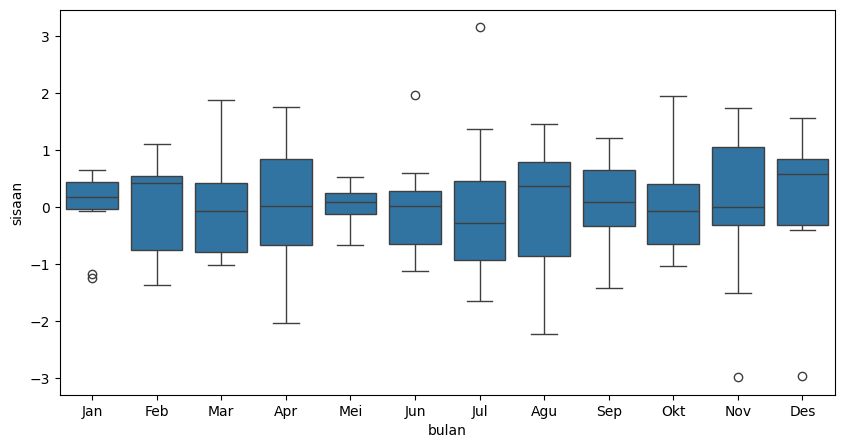

In [88]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

### Interpretasi Residual terhadap Waktu

Residual terlihat bergerak secara acak di sekitar nilai nol dan tidak lagi menunjukkan pola musiman yang teratur. Hal ini menunjukkan bahwa pola musiman utama pada data sudah berhasil dijelaskan oleh model, sehingga tidak banyak pola sistematis yang tersisa pada residual.

### Interpretasi Residual vs Fitted

Residual terlihat tersebar di sekitar nol dan tidak menunjukkan pola tertentu. Beberapa titik terlihat mengelompok secara vertikal karena observasi pada bulan yang sama memiliki nilai fitted yang sama atau hampir sama. Secara umum, tidak terlihat pola sistematis yang kuat pada residual, sehingga model sudah cukup baik dalam menangkap pola musiman data.

### Interpretasi Boxplot Residual

Dari boxplot terlihat bahwa median residual pada sebagian besar bulan berada di sekitar nol. Walaupun terdapat beberapa outlier dan perbedaan sebaran antarbulan, tidak terlihat satu bulan tertentu yang secara konsisten menghasilkan residual positif atau negatif. Hal ini menunjukkan bahwa model sudah cukup baik dalam menangkap pola musiman bulanan.

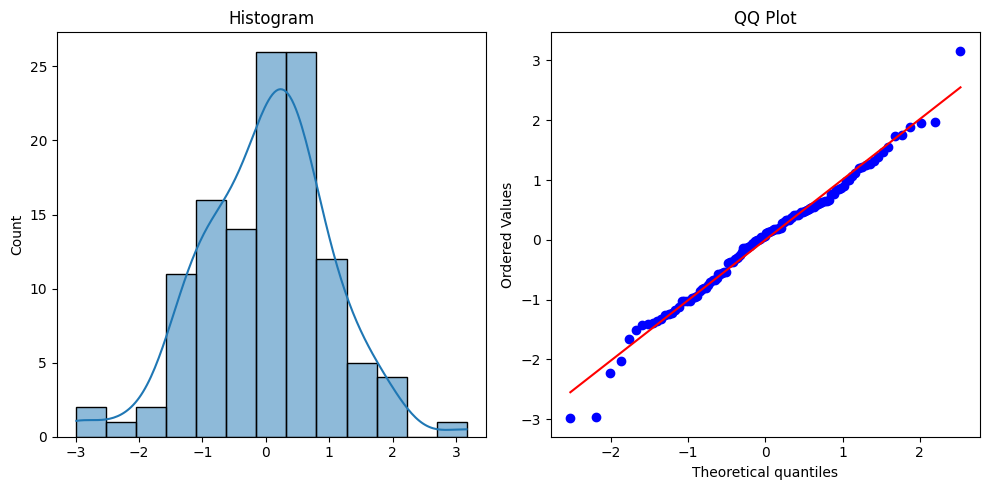

In [89]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

### Interpretasi Histogram dan QQ Plot

Histogram residual terlihat relatif simetris dan cukup mendekati bentuk distribusi normal. Pada QQ Plot, sebagian besar titik juga mengikuti garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Secara visual, residual dapat dikatakan cukup mendekati distribusi normal.

Berdasarkan plot diagnostik, model musiman sudah cukup sesuai. Residual berfluktuasi di sekitar nol, tidak menunjukkan pola musiman yang masih tersisa, dan distribusinya secara visual cukup mendekati normal.Jadi, model sudah mampu menjelaskan sebagian besar pola musiman yang terdapat pada data.

Hitunglah statistik uji untuk mengecek asumsi model

In [90]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [91]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [92]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.307e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.15e-245
Time:                        13:18:36   Log-Likelihood:                -239.31
No. Observations:                 120   AIC:                             502.6
Df Residuals:                     108   BIC:                             536.1
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -453.7086      0.593   -765.672      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

####Interpretasi Model Musiman dengan Intersep

Berdasarkan hasil regresi, diperoleh nilai $R^2$ sebesar **1.000** dan adjusted $R^2$ sebesar **1.000**. Hal ini menunjukkan bahwa hampir seluruh variasi nilai deret dapat dijelaskan oleh komponen musiman dalam model. Nilai **Prob(F-statistic) = 3.15 \times 10^{-245}** juga jauh lebih kecil dari 0.05, sehingga model secara keseluruhan signifikan.

Pada model dengan intersep, bulan **Januari** digunakan sebagai kategori referensi. Oleh karena itu, nilai konstanta sebesar **-453.7086** merupakan nilai dugaan rata-rata deret pada bulan Januari.

Koefisien bulan lainnya menunjukkan selisih nilai rata-rata bulan tersebut dibandingkan Januari. Sebagai contoh, koefisien Februari sebesar **49.0527** berarti nilai rata-rata bulan Februari sekitar 49.0527 satuan lebih tinggi dibandingkan Januari. Dengan demikian, nilai dugaan untuk Februari adalah:

$$
-453.7086 + 49.0527 = -404.6559
$$

Koefisien Maret sebesar **225.7142** berarti nilai rata-rata bulan Maret sekitar 225.7142 satuan lebih tinggi dibandingkan Januari, sehingga:

$$
-453.7086 + 225.7142 = -227.9944
$$

Untuk bulan Juli, koefisien sebesar **1049.7129** menunjukkan bahwa nilai rata-rata Juli sekitar 1049.7129 satuan lebih tinggi dibandingkan Januari. Nilai dugaan Juli adalah:

$$
-453.7086 + 1049.7129 = 596.0043
$$

Dengan cara yang sama, koefisien bulan lainnya dapat dimaknai sebagai selisih nilai rata-rata masing-masing bulan terhadap Januari sebagai bulan referensi.

Seluruh koefisien memiliki $p\text{-value} = 0.000 < 0.05$, sehingga perbedaan nilai antara masing-masing bulan dan bulan referensi signifikan secara statistik.

####Perbandingan Model dengan Intersep dan Tanpa Intersep

Model dengan intersep dan model tanpa intersep pada dasarnya menghasilkan nilai fitted yang sama, tetapi cara menginterpretasikan koefisiennya berbeda.

Pada model **tanpa intersep**, semua 12 dummy bulan dimasukkan ke dalam model. Oleh karena itu, setiap koefisien langsung menunjukkan nilai rata-rata deret untuk bulan tersebut.

Sebaliknya, pada model **dengan intersep**, satu bulan dijadikan sebagai kategori referensi, yaitu Januari. Nilai intersep menunjukkan rata-rata bulan Januari, sedangkan koefisien bulan Februari sampai Desember menunjukkan selisih nilai rata-rata bulan tersebut terhadap Januari.

Sebagai contoh, pada model tanpa intersep nilai rata-rata Februari dapat langsung dibaca dari koefisien Februari, yaitu sekitar **-404.656**. Pada model dengan intersep, nilai Februari diperoleh dari:

$$
\hat{Y}_{Februari}
=
\beta_0 + \beta_{Februari}
$$

$$
=
-453.7086 + 49.0527
=
-404.6559
$$

Hasilnya sama dengan model tanpa intersep. Jadi, perbedaan kedua model bukan pada nilai prediksinya, tetapi pada cara parameterisasi dan cara membaca koefisien regresinya.


Apakah model dengan intersep sudah memenuhi asumsi regresi?

####Pengecekan Asumsi Model dengan Intersep

Berdasarkan output regresi, nilai **Durbin-Watson sebesar 2.181**. Nilai ini cukup dekat dengan 2, sehingga tidak terdapat indikasi autokorelasi residual yang kuat.

Untuk asumsi normalitas, diperoleh nilai **Prob(Omnibus) sebesar 0.197** dan **Prob(Jarque-Bera) sebesar 0.207**. Kedua nilai tersebut lebih besar dari 0.05, sehingga tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi.

Nilai skewness sebesar **-0.160** juga cukup dekat dengan nol, yang menunjukkan bahwa distribusi residual relatif simetris. Nilai kurtosis sebesar **3.726** sedikit lebih besar dari 3, tetapi masih tidak menunjukkan penyimpangan normalitas yang serius, terutama karena hasil uji Jarque-Bera tidak signifikan.

Selain itu, nilai **Condition Number sebesar 12.9** relatif rendah, sehingga tidak menunjukkan adanya masalah multikolinearitas yang serius. Secara umum, berdasarkan informasi diagnostik pada output OLS, model dengan intersep sudah cukup memenuhi asumsi regresi. Namun, untuk memastikan asumsi homoskedastisitas secara lebih lengkap, tetap perlu melihat plot residual atau melakukan uji seperti Breusch-Pagan jika tersedia.

In [93]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [94]:
# Parameter
np.random.seed(1021)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 10.5, 210 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


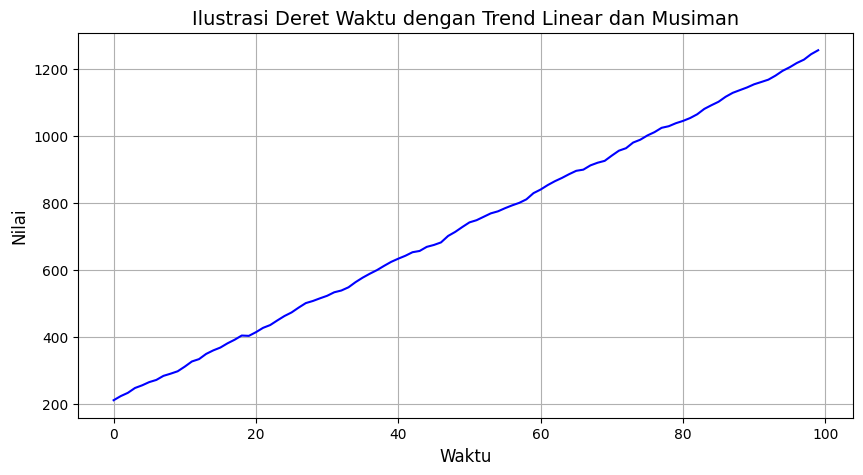

In [95]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

### Interpretasi Grafik

Berdasarkan grafik, terlihat bahwa nilai deret secara umum terus meningkat dari sekitar 200 pada awal periode hingga lebih dari 1200 pada akhir periode. Hal ini menunjukkan adanya **trend linear positif** yang cukup kuat, yaitu nilai deret cenderung meningkat seiring bertambahnya waktu.

Selain trend linear, terdapat fluktuasi kecil di sekitar garis trend yang menunjukkan adanya komponen musiman. Namun, dibandingkan dengan trend linearnya, pola musiman pada grafik ini tidak terlihat terlalu kuat karena amplitudo fluktuasinya relatif kecil.Secara keseluruhan, pola deret lebih didominasi oleh **trend linear positif**, dengan adanya variasi musiman yang menyebabkan nilai deret sedikit berfluktuasi di sekitar trend tersebut.

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [96]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [97]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [98]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.171e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.40e-189
Time:                        13:18:36   Log-Likelihood:                -197.88
No. Observations:                 100   AIC:                             421.8
Df Residuals:                      87   BIC:                             455.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      210.3010      0.699    300.678      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?


Berdasarkan hasil regresi, model memasukkan komponen musiman berupa dummy bulan dan komponen trend berupa variabel period. Karena model tidak menggunakan intersep, koefisien masing-masing bulan menunjukkan nilai dasar deret untuk bulan tersebut, sedangkan koefisien period menunjukkan perubahan nilai deret seiring bertambahnya waktu.

Koefisien period sebesar **10.4978** menunjukkan bahwa setiap bertambah satu periode waktu, nilai deret diperkirakan meningkat sekitar 10.4978, dengan pengaruh musiman bulan dianggap tetap. Nilai $p\text{-value} = 0.000 < 0.05$ menunjukkan bahwa trend waktu tersebut signifikan.

Sementara itu, koefisien dummy bulan menunjukkan perbedaan pola musiman pada setiap bulan. Sebagai contoh, koefisien Januari sebesar **210.3010**, Februari sebesar **212.5145**, dan April sebesar **215.2394**. Nilai koefisien tersebut merupakan komponen dasar masing-masing bulan sebelum ditambahkan pengaruh trend waktu.

Secara umum, nilai prediksi dapat dituliskan sebagai:

$$
\hat{Y}_t = \beta_{\text{bulan}} + 10.4978t
$$

dengan $\beta_{\text{bulan}}$ disesuaikan dengan bulan pada periode tersebut.

Sebagai contoh, jika suatu pengamatan berada pada bulan Januari, maka modelnya menjadi:

$$
\hat{Y}_t = 210.3010 + 10.4978t
$$

sedangkan untuk bulan April:

$$
\hat{Y}_t = 215.2394 + 10.4978t
$$

Dengan demikian, koefisien bulan menangkap **komponen musiman**, sedangkan koefisien period menangkap **trend linear** pada deret. Seluruh koefisien memiliki $p\text{-value} < 0.05$, sehingga komponen trend maupun musiman dalam model signifikan.

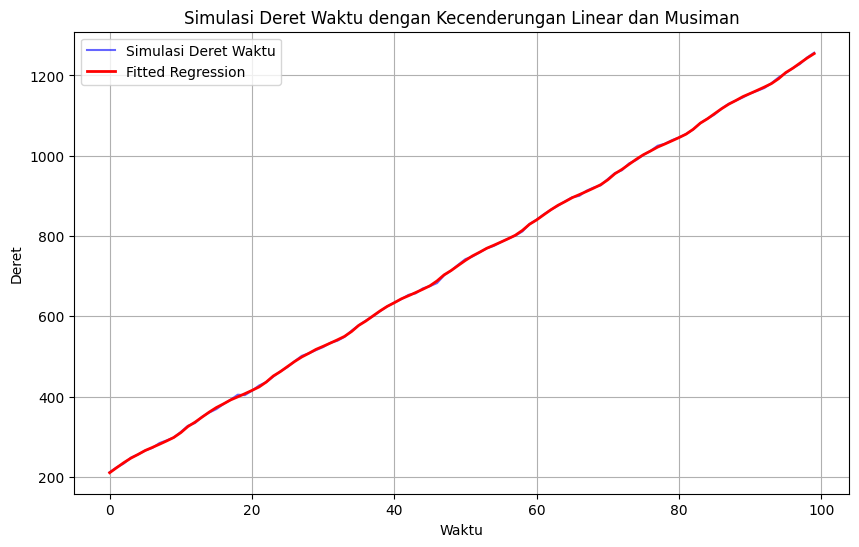

In [99]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

### Pengecekan Asumsi Model

Berdasarkan grafik, garis **Fitted Regression** (merah) hampir berimpit dengan data simulasi (biru) sepanjang periode pengamatan. Hal ini menunjukkan bahwa model sudah mampu menangkap pola utama pada deret, yaitu trend linear dan komponen musiman, dengan cukup baik.

Berdasarkan output OLS, nilai **Durbin-Watson sebesar 2.185** cukup dekat dengan 2. Hal ini menunjukkan bahwa tidak terdapat indikasi autokorelasi residual yang kuat. Selain itu, nilai **Prob(Jarque-Bera) sebesar 0.580 > 0.05**, sehingga tidak terdapat cukup bukti untuk menolak asumsi normalitas residual.

Dengan demikian, berdasarkan informasi yang tersedia, tidak terlihat adanya pelanggaran asumsi yang serius pada model. Model sudah cukup baik dalam menggambarkan pola deret. Namun, untuk memastikan asumsi homoskedastisitas, perlu dilakukan pemeriksaan tambahan menggunakan plot residual atau uji seperti Breusch-Pagan karena asumsi tersebut tidak dapat disimpulkan hanya dari grafik aktual dan fitted serta output OLS.

In [100]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [101]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

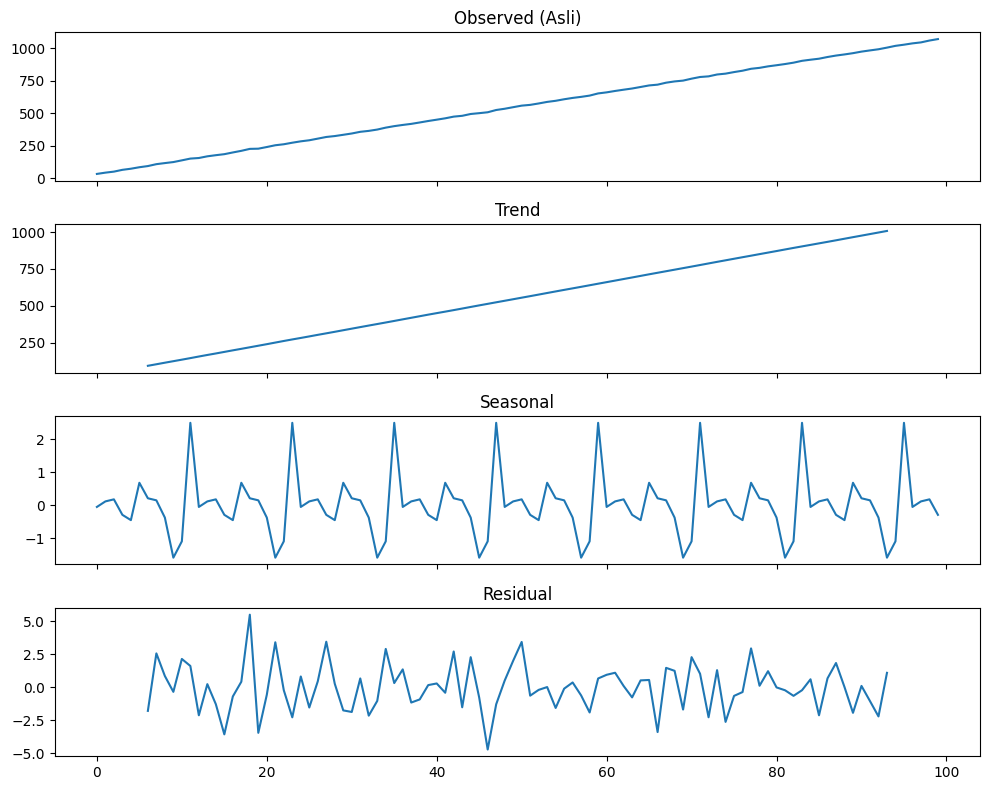

In [102]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?


Berdasarkan hasil dekomposisi, deret waktu dapat dipisahkan menjadi komponen **Observed, Trend, Seasonal**, dan **Residual**.

Pada komponen **Observed (Asli)**, terlihat bahwa nilai deret secara umum terus meningkat dari awal hingga akhir periode. Meskipun terdapat sedikit fluktuasi, pola yang paling dominan adalah peningkatan nilai seiring bertambahnya waktu.

Komponen **Trend** menunjukkan pola peningkatan yang hampir membentuk garis lurus. Hal ini menunjukkan bahwa deret memiliki **trend linear positif** yang cukup kuat, yaitu nilai deret cenderung meningkat secara relatif konstan dari waktu ke waktu.

Komponen **Seasonal** menunjukkan pola naik-turun yang berulang secara teratur. Pola yang relatif sama muncul kembali pada beberapa periode, sehingga menunjukkan adanya **komponen musiman** pada deret. Namun, jika dibandingkan dengan trend, besar variasi musimannya relatif kecil sehingga pada data asli pola musiman tidak terlalu terlihat.

Sementara itu, komponen **Residual** berfluktuasi secara acak di sekitar nilai nol dan tidak menunjukkan pola trend maupun musiman yang jelas. Hal ini menunjukkan bahwa sebagian besar pola sistematis pada data sudah dapat dijelaskan oleh komponen trend dan seasonal.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa deret lebih didominasi oleh **trend linear positif**, disertai pola musiman yang berulang dan komponen acak pada residual.

In [103]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

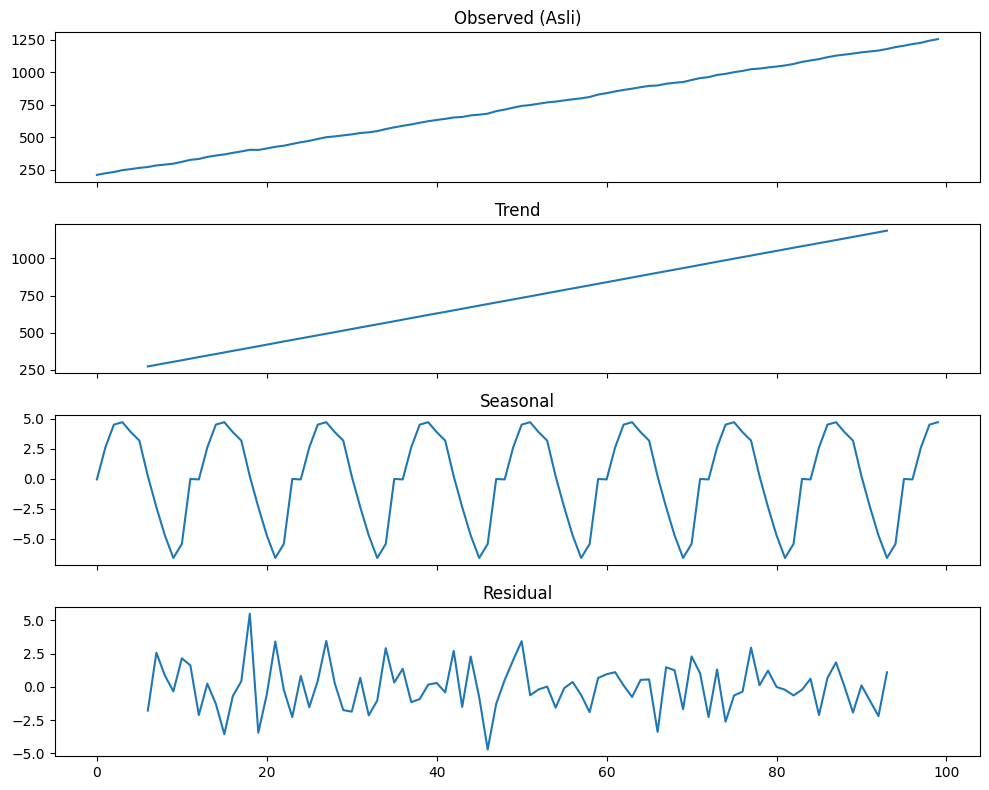

In [104]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

### Interpretasi Hasil Dekomposisi Deret

Berdasarkan hasil dekomposisi, deret dapat dipisahkan menjadi komponen **Observed, Trend, Seasonal**, dan **Residual**.

Pada komponen **Observed (Asli)**, nilai deret terlihat terus meningkat dari awal hingga akhir periode. Pola peningkatan ini menunjukkan adanya kecenderungan positif pada deret, meskipun terdapat sedikit fluktuasi di sepanjang waktu.

Komponen **Trend** menunjukkan pola peningkatan yang hampir membentuk garis lurus. Artinya, deret memiliki **trend linear positif**, yaitu nilai deret cenderung meningkat secara relatif konstan seiring bertambahnya waktu.

Komponen **Seasonal** menunjukkan pola naik-turun yang berulang secara teratur. Besarnya fluktuasi musiman juga terlihat relatif sama dari awal hingga akhir periode, yaitu berada pada kisaran yang kurang lebih tetap. Hal ini menunjukkan adanya pola musiman dengan amplitudo yang relatif konstan.

Sementara itu, komponen **Residual** berfluktuasi secara acak di sekitar nilai nol dan tidak menunjukkan pola trend maupun musiman yang jelas. Artinya, setelah komponen trend dan seasonal dipisahkan, variasi yang tersisa lebih banyak berupa komponen acak.

Berdasarkan pola tersebut, **model dekomposisi aditif lebih sesuai** untuk deret ini karena besarnya fluktuasi musiman relatif konstan meskipun level atau trend deret terus meningkat.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [112]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1021)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 1.05, 210 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

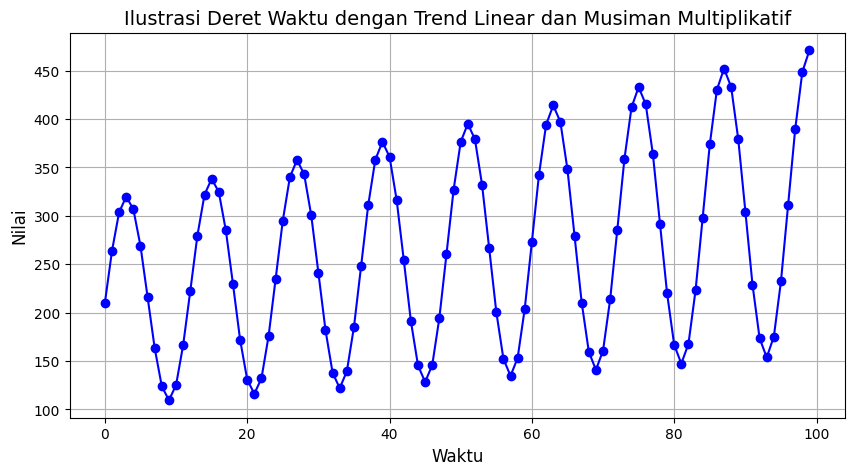

In [113]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()


Berdasarkan grafik, terlihat bahwa deret memiliki **trend linear positif**, yaitu nilai deret secara umum meningkat dari awal hingga akhir periode. Di samping trend tersebut, terdapat pola naik-turun yang berulang secara teratur, yang menunjukkan adanya **komponen musiman**.

Berbeda dengan pola musiman aditif, pada grafik ini besarnya fluktuasi musiman cenderung meningkat seiring dengan meningkatnya level deret. Pada awal periode, jarak antara titik puncak dan lembah relatif lebih kecil, sedangkan pada periode berikutnya jarak tersebut cenderung semakin besar.

Pola ini menunjukkan bahwa pengaruh musimannya bersifat **multiplikatif**, karena besar kecilnya efek musiman bergantung pada level deret. Ketika level trend meningkat, amplitudo fluktuasi musimannya juga ikut meningkat.

Dengan demikian, deret ini memiliki **trend linear positif dan pola musiman multiplikatif**, sehingga model multiplikatif lebih sesuai untuk menggambarkan pola deret tersebut.

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [114]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

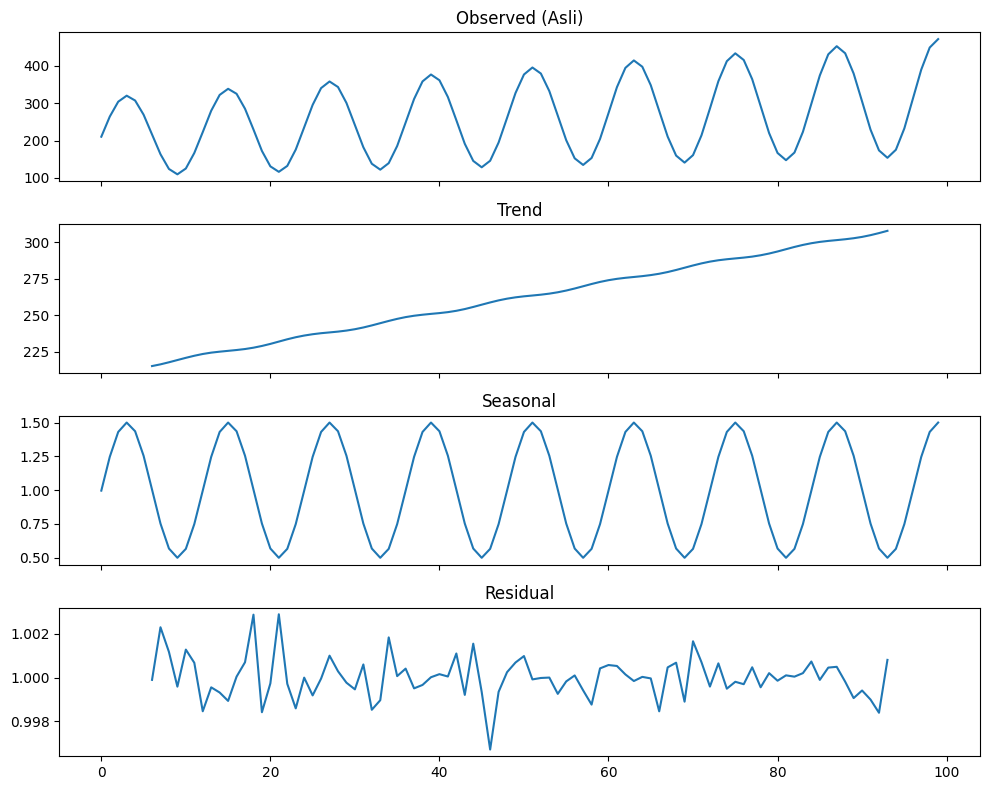

In [115]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?


Berdasarkan hasil dekomposisi, deret dipisahkan menjadi komponen **Observed, Trend, Seasonal**, dan **Residual**.

Pada komponen **Observed (Asli)**, terlihat bahwa nilai deret memiliki pola naik-turun yang berulang dan secara keseluruhan levelnya juga semakin meningkat. Selain itu, jarak antara puncak dan lembah cenderung semakin besar seiring meningkatnya level deret. Hal ini menunjukkan adanya trend positif yang disertai pola musiman multiplikatif.

Komponen **Trend** menunjukkan peningkatan yang cukup stabil dari waktu ke waktu. Nilai trend meningkat dari sekitar 215 pada awal periode menjadi lebih dari 300 pada akhir periode, sehingga menunjukkan adanya **trend positif** pada deret.

Komponen **Seasonal** menunjukkan pola yang berulang secara teratur dengan nilai faktor musiman sekitar 0.5 sampai 1.5. Pada model multiplikatif, nilai seasonal di atas 1 menunjukkan bahwa pada periode tersebut efek musiman meningkatkan nilai deret dari level trend, sedangkan nilai seasonal di bawah 1 menunjukkan bahwa efek musiman menurunkan nilai deret dari level trend.

Komponen **Residual** berfluktuasi sangat dekat dengan nilai 1 dan tidak menunjukkan pola tertentu. Pada dekomposisi multiplikatif, residual yang berada di sekitar 1 menunjukkan bahwa setelah komponen trend dan seasonal diperhitungkan, hanya terdapat sedikit variasi acak yang tersisa.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa pola deret dapat dijelaskan dengan baik oleh kombinasi **trend positif dan pola musiman multiplikatif**. Hal ini juga terlihat dari residual yang relatif kecil dan bergerak di sekitar nilai 1.

In [116]:
# Parameter
np.random.seed(1021)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

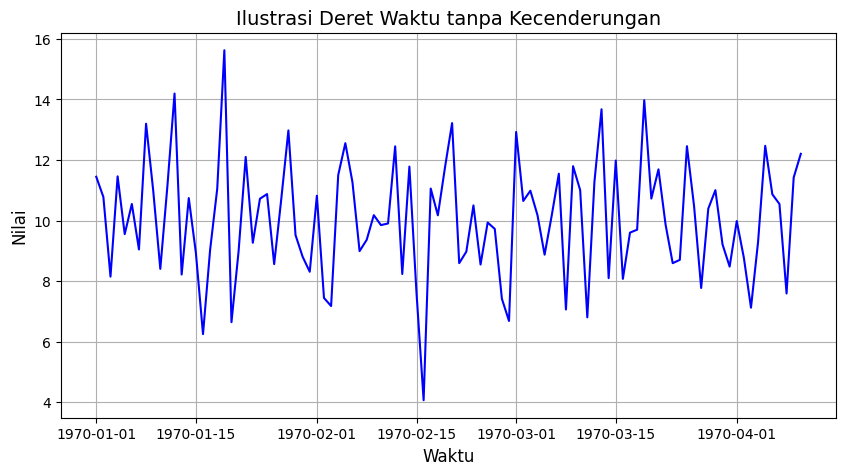

In [117]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()


Berdasarkan grafik, nilai deret terlihat berfluktuasi secara acak di sekitar level yang relatif konstan, yaitu sekitar **10**. Sepanjang periode pengamatan tidak terlihat adanya pola peningkatan maupun penurunan yang berlangsung secara konsisten.

Selain itu, tidak terlihat pola naik-turun yang berulang secara teratur pada periode tertentu, sehingga tidak terdapat indikasi pola musiman yang jelas. Meskipun terdapat beberapa nilai yang cukup tinggi maupun rendah, perubahan tersebut lebih menunjukkan variasi acak dari waktu ke waktu.

Dengan demikian, deret tersebut dapat dikatakan **tidak memiliki kecenderungan atau trend tertentu**. Nilai deret cenderung bergerak di sekitar rata-rata yang relatif tetap dengan fluktuasi yang bersifat acak.

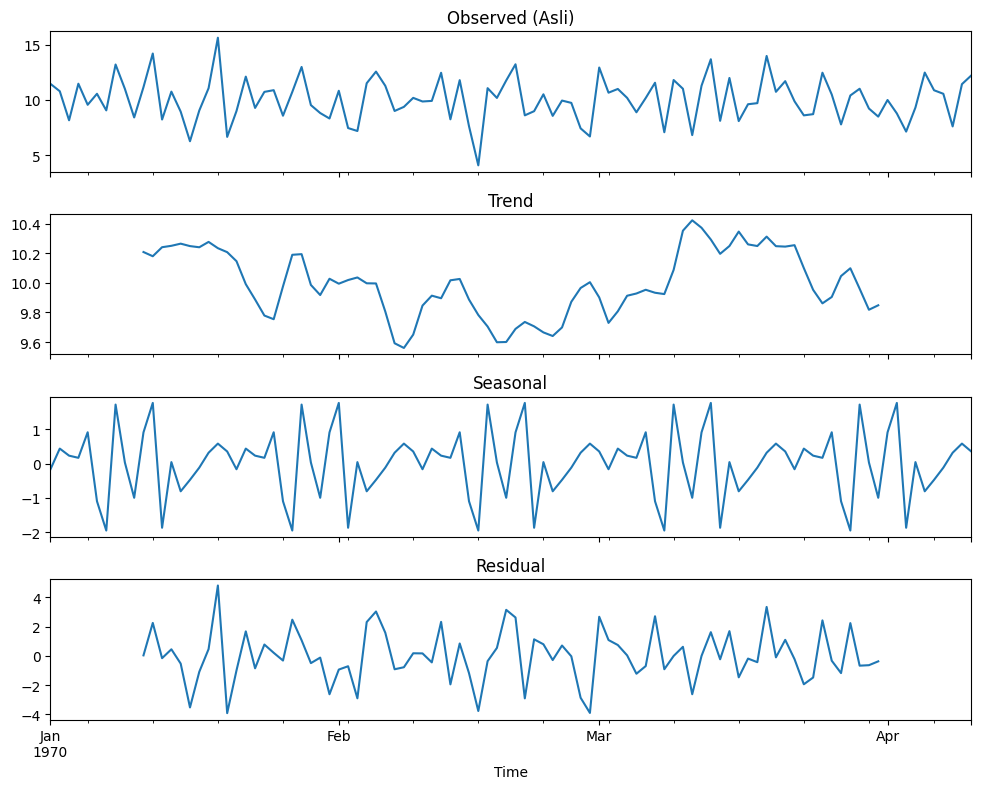

In [118]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

Berdasarkan hasil dekomposisi, deret waktu dipisahkan menjadi komponen **Observed, Trend, Seasonal**, dan **Residual**.

Pada komponen **Observed (Asli)**, nilai deret terlihat berfluktuasi di sekitar level yang relatif konstan, yaitu sekitar 10. Tidak terlihat adanya pola peningkatan atau penurunan yang berlangsung secara konsisten dari awal hingga akhir periode.

Komponen **Trend** juga berada pada kisaran yang relatif sempit, yaitu sekitar 9.6 sampai 10.4. Meskipun terdapat sedikit kenaikan dan penurunan, perubahan tersebut tidak menunjukkan arah yang konsisten. Dengan demikian, tidak terdapat kecenderungan atau trend jangka panjang yang kuat pada deret.

Pada komponen **Seasonal**, terlihat adanya fluktuasi di sekitar nol. Namun, pola naik-turun tersebut tidak menunjukkan bentuk yang berulang secara teratur dan konsisten. Oleh karena itu, tidak terlihat adanya pola musiman yang kuat pada deret.

Komponen **Residual** berfluktuasi secara acak di sekitar nol, baik ke arah positif maupun negatif. Tidak terlihat pola tertentu yang sistematis pada residual, sehingga variasi yang tersisa lebih banyak menggambarkan komponen acak.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa deret **tidak memiliki trend maupun pola musiman yang kuat**. Perubahan nilai deret lebih didominasi oleh fluktuasi acak di sekitar level rata-rata yang relatif konstan.